# 02 — Triple-Barrier Labels (AFML §3)

This notebook demonstrates Lopez de Prado's triple-barrier labeling method
on synthetic BTCUSDT 1-minute bars. We:

1. Generate 6 months of realistic price data (GBM with drift).
2. Compute exponentially-weighted volatility.
3. Apply the triple barrier with pt_sl=(2.0, 2.0) and a 4-hour vertical barrier.
4. Visualize 50 random events showing the three barriers and which was hit.
5. Plot the label distribution.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

# Generate 6 months of 1-minute bars (~262,800 bars)
n_bars = 60 * 24 * 180  # 180 days
idx = pd.date_range("2024-01-01", periods=n_bars, freq="min")

# Geometric Brownian Motion: realistic BTC-like volatility
mu = 0.0  # zero drift
sigma = 0.0003  # per-minute vol (~0.55% per hour, ~13% annualized)
log_returns = np.random.normal(mu, sigma, n_bars)
log_returns[0] = 0
prices = 42000.0 * np.exp(np.cumsum(log_returns))
close = pd.Series(prices, index=idx, name="close")

print(f"Price series: {len(close)} bars")
print(f"Date range: {close.index[0]} to {close.index[-1]}")
print(f"Price range: ${close.min():.0f} - ${close.max():.0f}")

Price series: 259200 bars
Date range: 2024-01-01 00:00:00 to 2024-06-28 23:59:00
Price range: $39649 - $46965


## Step 1: Compute Volatility

Using exponentially-weighted standard deviation of log returns (AFML §3.1).
The span of 1440 bars = 1 day of 1-minute data.

In [2]:
from tessera.labels.triple_barrier import (
    apply_triple_barrier,
    compute_volatility,
    get_bins,
    make_events,
)

vol = compute_volatility(close, span=1440, min_periods=60)
print(f"Volatility range: {vol.min():.6f} - {vol.max():.6f}")
print(f"Mean volatility: {vol.mean():.6f}")
print(f"Non-null values: {vol.notna().sum()}")

Volatility range: 0.000269 - 0.000320
Mean volatility: 0.000300
Non-null values: 259140


## Step 2: Apply Triple Barrier

We sample events every 60 minutes (hourly), apply pt_sl=(2.0, 2.0) meaning
barriers are set at ±2× the local volatility, and use a 4-hour vertical barrier (240 bars).

In [3]:
# Sample events every 60 bars (hourly)
event_timestamps = close.index[::60]
# Trim to where volatility is available and leave room for vertical barrier
event_timestamps = event_timestamps[
    (event_timestamps >= vol.dropna().index[0]) & (event_timestamps <= close.index[-241])
]

events = make_events(close, event_timestamps, vol, vertical_bars=240)
print(f"Number of events: {len(events)}")

# Apply triple barrier
tb = apply_triple_barrier(events, close, pt_sl=(2.0, 2.0))
bins = get_bins(tb, close)

print("\nLabel distribution:")
print(bins["bin"].value_counts().sort_index())
print("\nLabel proportions:")
print(bins["bin"].value_counts(normalize=True).sort_index().round(3))

Number of events: 4315



Label distribution:
bin
-1    2122
 1    2193
Name: count, dtype: int64

Label proportions:
bin
-1    0.492
 1    0.508
Name: proportion, dtype: float64


## Step 3: Visualize 50 Random Events

Each subplot shows the price path from event entry to the vertical barrier,
with the upper (green) and lower (red) barriers drawn as horizontal lines.
The dot marks which barrier was hit first.

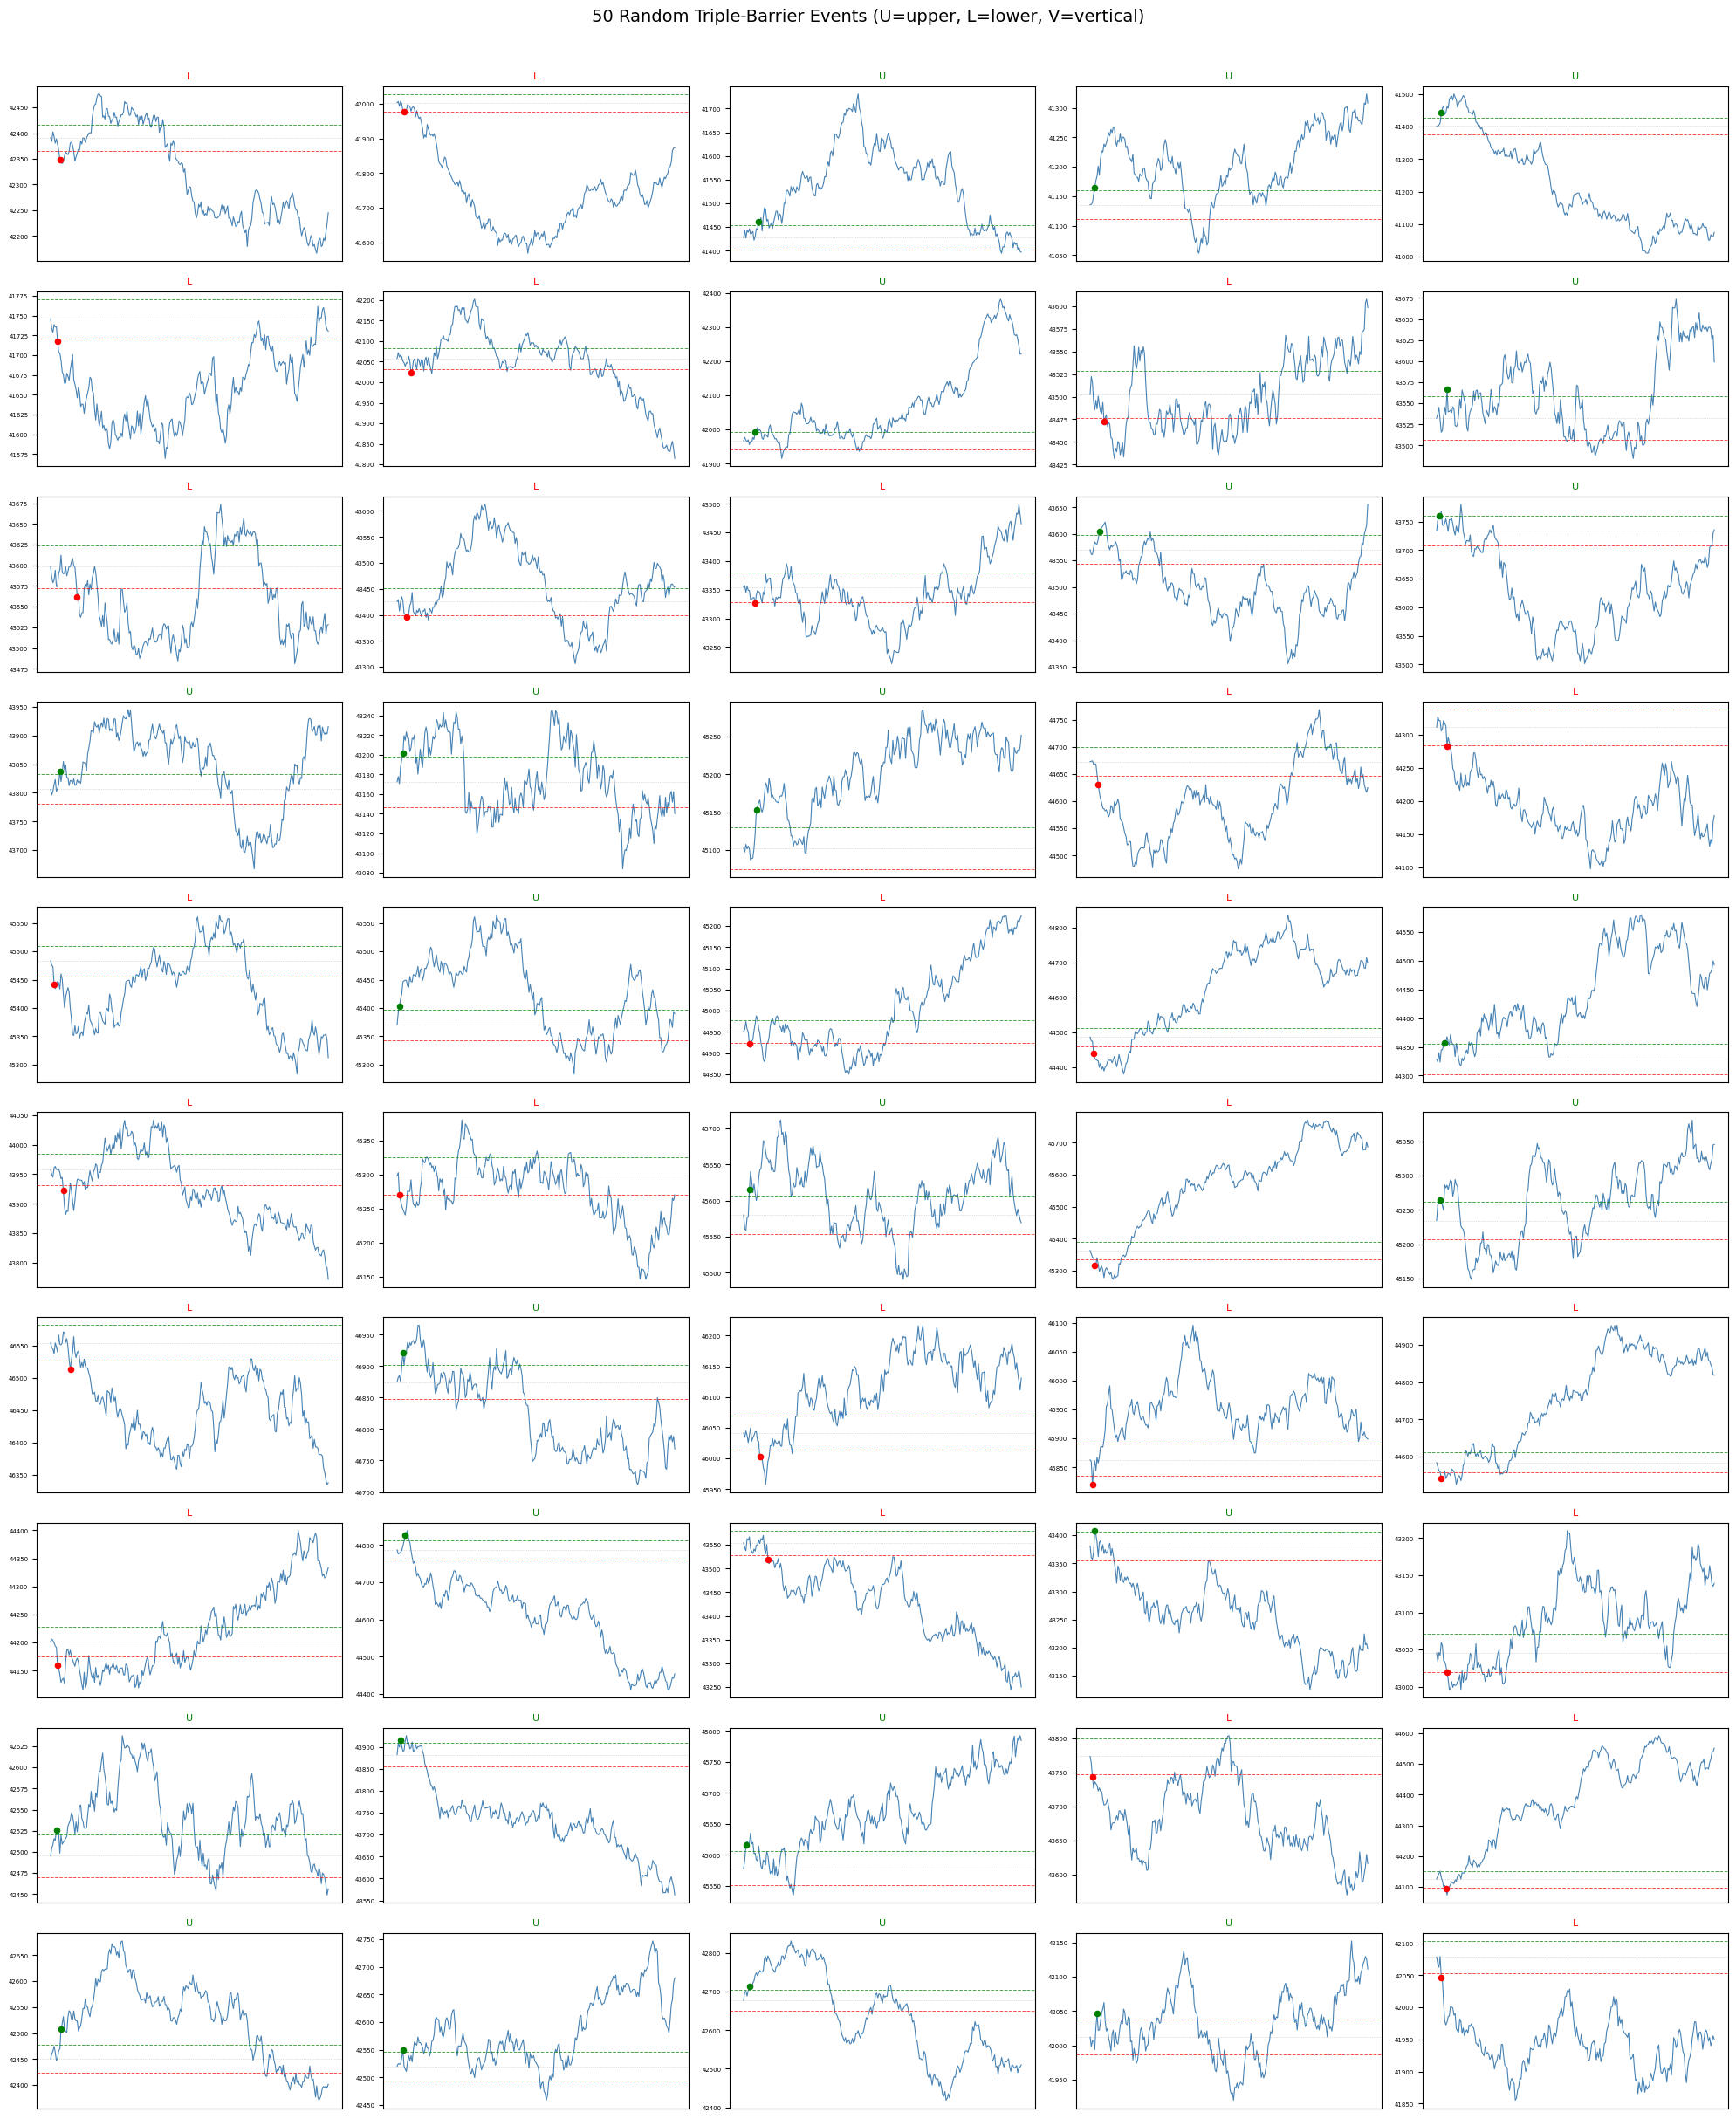

Saved to docs/figures/triple_barrier_events.png


In [4]:
# Select 50 random events
sample_idx = np.random.choice(len(events), size=min(50, len(events)), replace=False)
sample_idx.sort()
sample_events = events.iloc[sample_idx]
sample_tb = tb.iloc[sample_idx]
sample_bins = bins.iloc[sample_idx]

fig, axes = plt.subplots(10, 5, figsize=(20, 24))
axes = axes.flatten()

for i, (t0, event) in enumerate(sample_events.iterrows()):
    ax = axes[i]
    t1 = event["t1"]
    trgt = event["trgt"]

    path = close.loc[t0:t1]
    entry_price = close.loc[t0]

    ax.plot(range(len(path)), path.values, color="steelblue", linewidth=0.8)

    # Barrier lines
    upper_price = entry_price * (1 + 2.0 * trgt)
    lower_price = entry_price * (1 - 2.0 * trgt)
    ax.axhline(upper_price, color="green", linestyle="--", alpha=0.7, linewidth=0.7)
    ax.axhline(lower_price, color="red", linestyle="--", alpha=0.7, linewidth=0.7)
    ax.axhline(entry_price, color="gray", linestyle=":", alpha=0.5, linewidth=0.5)

    # Mark the hit
    label = sample_bins["bin"].iloc[i]
    colors = {1: "green", -1: "red", 0: "orange"}
    labels_text = {1: "U", -1: "L", 0: "V"}

    t_first = sample_tb["t_first"].iloc[i]
    if pd.notna(t_first) and t_first in close.index:
        hit_bar = close.index.get_loc(t_first) - close.index.get_loc(t0)
        hit_price = close.loc[t_first]
        ax.scatter([hit_bar], [hit_price], color=colors[label], s=20, zorder=5)

    ax.set_title(f"{labels_text[label]}", fontsize=8, color=colors[label])
    ax.tick_params(labelsize=5)
    ax.set_xticks([])

plt.suptitle("50 Random Triple-Barrier Events (U=upper, L=lower, V=vertical)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../docs/figures/triple_barrier_events.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/figures/triple_barrier_events.png")

## Step 4: Label Distribution

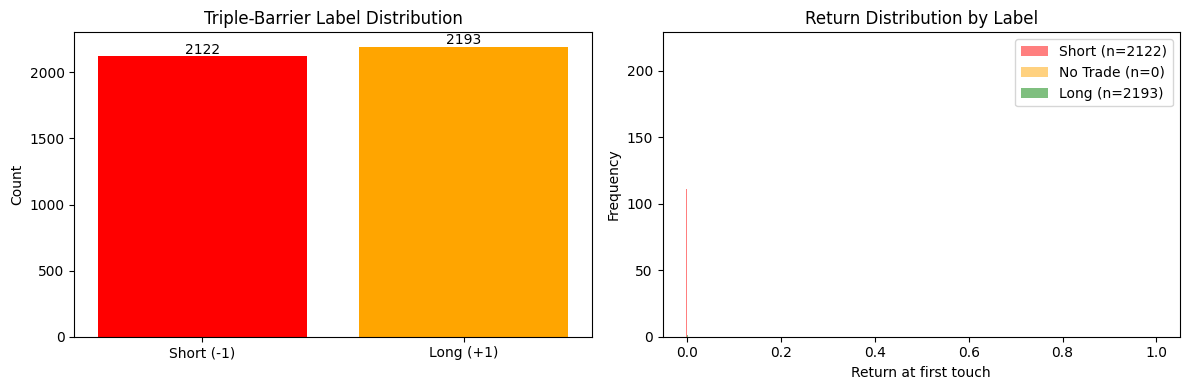

Saved to docs/figures/label_distribution.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = bins["bin"].value_counts().sort_index()
colors = ["red", "orange", "green"]
labels_map = {-1: "Short (-1)", 0: "No Trade (0)", 1: "Long (+1)"}
ax1.bar([labels_map[k] for k in counts.index], counts.values, color=colors)
ax1.set_ylabel("Count")
ax1.set_title("Triple-Barrier Label Distribution")
for i, v in enumerate(counts.values):
    ax1.text(i, v + 20, str(v), ha="center", fontsize=10)

# Return distribution by label
for label, color, name in [(-1, "red", "Short"), (0, "orange", "No Trade"), (1, "green", "Long")]:
    subset = bins[bins["bin"] == label]["ret"]
    ax2.hist(subset, bins=50, alpha=0.5, color=color, label=f"{name} (n={len(subset)})")
ax2.set_xlabel("Return at first touch")
ax2.set_ylabel("Frequency")
ax2.set_title("Return Distribution by Label")
ax2.legend()

plt.tight_layout()
plt.savefig("../docs/figures/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/figures/label_distribution.png")